# Instagrapi data collection

the files secrets.json, session.json and my_data.json are added to the .gitgnore file

## login

In [116]:
# get credentials
import json

def load_json(filename):
    with open(filename, 'r') as f:
        data = json.load(f)
    return data

credentials = load_json('secrets.json')
ACCOUNT_USERNAME = credentials['ACCOUNT_USERNAME']
ACCOUNT_PASSWORD = credentials['ACCOUNT_PASSWORD']

In [ ]:
# FIRST ACCESS
import instagrapi as ig

cl = ig.Client()
# adds a random delay between 1 and 3 seconds after each request, if You want more than users info
# cl.delay_range = [1, 3]
cl.login(ACCOUNT_USERNAME, ACCOUNT_PASSWORD)
cl.dump_settings("session.json")

In [ ]:
# NEW ACCESS WITH OLD SESSION
# reload later without entering credentials again
import instagrapi as ig

cl = ig.Client()
# adds a random delay between 1 and 3 seconds after each request
cl.delay_range = [1, 3]
cl.load_settings("session.json")
cl.login(ACCOUNT_USERNAME, ACCOUNT_PASSWORD)

True

## load data
main operations in data backups.
Very dangerous code, if You have already download the data.

In [118]:
import json

def load_json(filename):
    with open(filename, 'r') as f:
        data = json.load(f)
    return data

main_data = load_json('my_data.json')
print(len(main_data['users_ids']))
print(len(main_data['main_users']))
print(len(main_data['friends_list']))
print(len(main_data['users_info']))
print(len(main_data['profilepic']))

44741
221
92095
192
185


['torreshiatsu', 'fede.rausa']
fede.rausa
58579908747
{'id': '58579908747', 'username': 'fede.rausa', 'full_name': 'Federico Rausa', 'biography': 'Hesse, Dostoevskij, C.S. Lewis, Tolkien, Baricco', 'is_private': False, 'is_verified': False, 'is_business': False, 'followers_count': 192, 'following_count': 257, 'media_count': 6, 'city_name': None, 'latitude': None, 'longitude': None, 'account_type': 1, 'scraped': True, 'scraped_followers': True, 'scraped_following': True}
{'url': 'https://scontent-mxp2-1.cdninstagram.com/v/t51.2885-19/333747832_1318825358677933_5435806963414036324_n.jpg?stp=dst-jpg_e0_s150x150_tt6&efg=eyJ2ZW5jb2RlX3RhZyI6InByb2ZpbGVfcGljLmRqYW5nby44NjQuYzIifQ&_nc_ht=scontent-mxp2-1.cdninstagram.com&_nc_cat=101&_nc_oc=Q6cZ2QGBMTuGmFRwth7D1YsJvCPbUd7WhnCId1NT42K_WmRf9aihRSjIRa_7bAHdUKaJ4vs&_nc_ohc=gOPmbG1rxFUQ7kNvwFz-6Og&_nc_gid=Mlw1jsiB4TweKMGJVahpTA&edm=AEF8tYYBAAAA&ccb=7-5&ig_cache_key=GHiW5BOtVwb1dq8EAGRv4xGi3W9LbkULAAAB1501500j-ccb7-5&oh=00_AfcbtH6V_jX7NC06SHUnV8T5Sws
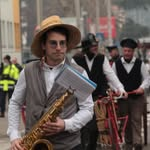
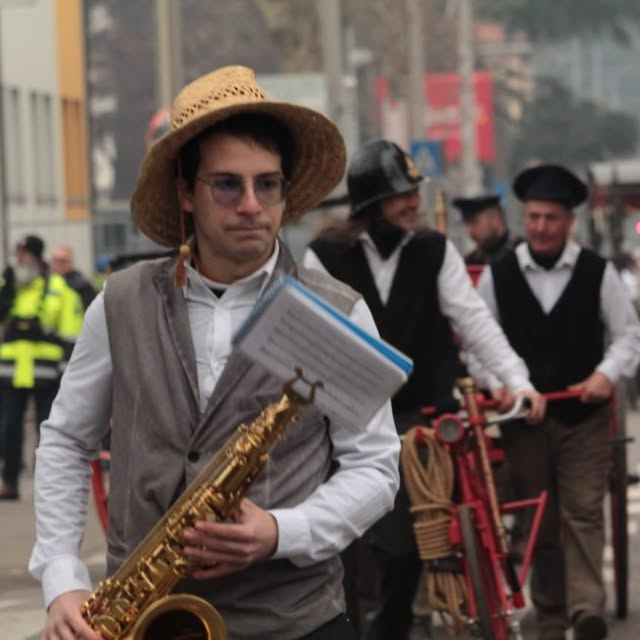

In [119]:
# security check of main_data content
print(main_data['friends_list'][0])
u = main_data['main_users'][0]
print(u)
print(main_data['users_ids'][u])
print(main_data['users_info'][u])
print(main_data['profilepic'][u])
print(main_data['friends_list'][0])

In [ ]:
# save data checkpoint
#DANGER: be sure You want to change the my_data.json file
#save_json(main_data, 'my_data.json')

In [ ]:
# initialize empty data
#DANGER: do this only if this folder doesn't contain data

# init_users = ['fede.rausa', 'saraaturri', 'lorenzo_gallinaro']
# main_data = {}
# main_data['users_ids'] = {}
# main_data['users_info'] = {}
# main_data['friends_list'] = []
# main_data['main_users'] = init_users
# main_data['profilepic'] = {}

#VERY BIG DANGER
############ save_json(main_data, 'my_data.json')

In [ ]:
# backup data in separate files

from tqdm import tqdm
import copy
import json

def save_json(data, filename):
    with open(filename, 'w') as f:
        json.dump(data, f, indent=4)


#save data in separated files
print(main_data.keys())

users_data = copy.deepcopy(main_data)
del users_data['friends_list']
del users_data['profilepic']
edges_data = copy.deepcopy(main_data)
edges_data = main_data['friends_list']
images_data = copy.deepcopy(main_data)
images_data = images_data['profilepic']
# small_images_data = copy.deepcopy(images_data)
# big_images_data = copy.deepcopy(images_data)

# # remove base64 data
# for u in tqdm(small_images_data):
#     if 'base64hd' in small_images_data[u]:
#         del small_images_data[u]['base64hd']

# # remove url data
# for u in tqdm(big_images_data):
#     if 'base64' in big_images_data[u]:
#         del big_images_data[u]['base64']

print(users_data.keys())
print(len(edges_data))
print(len(images_data))
# print(len(small_images_data))
# print(len(big_images_data))

save_json(users_data, 'users_data.json')
save_json(edges_data, 'edges_data.json')
save_json(images_data, 'images_data.json')
# save_json(small_images_data, 'small_images_data.json')
# save_json(big_images_data, 'big_images_data.json')


## define functions

In [121]:
# functions
# base functions

import time
from tqdm import tqdm
import numpy as np
import json
import os
from collections import Counter
import requests
import base64

def save_json(data, filename):
    with open(filename, 'w') as f:
        json.dump(data, f, indent=4)


def load_json(filename):
    with open(filename, 'r') as f:
        data = json.load(f)
    return data


def url_to_base64(image_url):
    try:
        response = requests.get(image_url)
        response.raise_for_status()
        
        base64_data = base64.b64encode(response.content).decode('utf-8')
        return f"data:image/jpeg;base64,{base64_data}"
    except Exception as e:
        print(f"Error: {e}")
        return None



def scrape_user(username = None, user_id = None, include_images=False):
    if user_id is None and username is None:
        raise ValueError("Either user_id or username must be provided.")
    if user_id is None:
        user_id = cl.user_id_from_username(username)

    user_info = cl.user_info(user_id)

    info = {
            'id': user_id,
            'username': username,
            'full_name': user_info.full_name,
            'biography': user_info.biography,
            'is_private': user_info.is_private,
            'is_verified': user_info.is_verified,
            'is_business': user_info.is_business,
            'followers_count': user_info.follower_count,
            'following_count': user_info.following_count,
            'media_count': user_info.media_count,
            'city_name': user_info.city_name,
            'latitude': user_info.latitude,
            'longitude': user_info.longitude,
            'account_type': user_info.account_type,
            'scraped' : True,
            'scraped_followers': False,
            'scraped_following': False,
        }
    
    if include_images:
        try:
            image_url = str(user_info.profile_pic_url)
            base64_string = url_to_base64(image_url)
        except Exception as e:
            print('image error: ', e )
            image_url = None
            base64_string = None
        try:
            imagehd_url = str(user_info.profile_pic_url_hd)
        except Exception as e:
            print('image error: ', e )
            imagehd_url = None
             
        image_data = {
            'url' : image_url,
            'urlhd' : imagehd_url,
            'base64' : base64_string
        }
       
        return info, image_data
    else:
        return info


def scrape_user_friends(user_id, username, max_amount = 500, get_followers = True, get_following = True):

    start0 = time.time()

    friends_list = []
    users_ids = {}

    print(f"Scraping friends of user: {username}")

    if get_followers:

        start1 = time.time()
        print(f"Scraping followers of user: {username}")
        followers = cl.user_followers(user_id, amount = max_amount)
        print('Followers scraped:', len(followers))
        print(round(time.time() - start1, 2))

        for id in list(followers.keys()):
            users_ids[followers[id].username] = id

        for name in list(users_ids.keys()):
            friends_list.append((name, username))

        print('Followers saved')
        print(round(time.time() - start1, 2))

    if get_following:
        
        start2 = time.time()
        print(f"Scraping following of user: {username}")
        following = cl.user_following_gql(user_id, amount = max_amount)
        print('Following scraped:', len(following))
        print(round(time.time() - start2, 2))

        #print(following)
        uids = [u.pk for u in following]
        unames = [u.username for u in following]        
        for i in range(len(uids)):
            users_ids[unames[i]] = uids[i]

        # for id in uids:
        #     users_ids[following[id].username] = id

        for name in list(users_ids.keys()):
            friends_list.append((username, name))

        print('Following saved')
        print(round(time.time() - start2, 2))
        

    print('operation completed in', round(time.time() - start0, 2), 'seconds')

    return friends_list, users_ids




def get_user_friends(stalked_user, friends_list):
    filter_friend = [ (a,b) for a,b in friends_list if a==stalked_user or b==stalked_user]
    return filter_friend


def exploration_score0(users_list, main_users, friends_list):
    '''user popularity / degree score, as a dictionary'''
    scores = {}
    for u in users_list:
        if u not in main_users:
            s = 0
            for a, b in friends_list:
                if a==u or b==u:
                    s+=1
            scores[u] = s
    return scores


def exploration_score(users_list, main_users, friends_list, remove_main = False):
    """Efficient user popularity / degree score as a dictionary.
    
    users_list : list of strings (usernames)
    main_users : list of strings (usernames) 
    friends_list: list of tuples of two strings (usernames-nodes in the graph network)   
    """
    
    # Count appearances of each user in friends_list
    counts = Counter()
    for a, b in friends_list:
        counts[a] += 1
        counts[b] += 1

    if remove_main:
        # Convert main_users to set for O(1) lookups
        main_set = set(main_users)
        # Build the score dictionary only for users not in main_users
        scores = {u: counts.get(u, 0) for u in users_list if u not in main_set}
    else:
        scores = dict(counts)

    return scores


def iterated_degree_voting(users_list, main_users, friends_list, iter=3, remove_main = False):
    ''' 
    Returns a score dictionary based on an iterated weigthed degree voting.
    At each iteration, the weight of the vote of a user is equal to his score.
    At the first iteration, the scores are 1 for all users
    At the second the score of a user becomes equal  to the degree of the user in the graph.
    From the third, the score is deterministic at each iteration.
    All the scores grow exponentially over the iterations, so a small number of iterations is
    suggested.

    users_list : list of strings (usernames)
    main_users : list of strings (usernames) 
    friends_list: list of tuples of two strings (usernames-nodes in the graph network)   

    '''

    scores = {u: 1 for u in set(users_list+main_users)}
    counts = Counter(scores)

    for i in range(iter):
        den = counts.total()
        print(den)
        #den = den ** den
        # Count appearances of each user in friends_list
        old_counts = counts.copy()
        for a, b in friends_list:
            counts[a] += old_counts[b] #int(old_counts[b]/den) #
            counts[b] += old_counts[a] #int(old_counts[a]/den) #

    if remove_main:
        # Convert main_users to set for O(1) lookups
        main_set = set(main_users)
        # Build the score dictionary only for users not in main_users
        scores = {u: counts.get(u, 0) for u in users_list if u not in main_set}
    else:
        scores = dict(counts)

    return scores


def iterated_degree_voting_rank(users_list, main_users, friends_list, iter=3, remove_main = False):

    scores = {u: 1 for u in set(users_list+main_users)}
    counts = Counter(scores)

    for i in range(iter):
        old_counts = counts.copy()
        counts = Counter()
        
        for a, b in friends_list:
            counts[a] += old_counts[b]
            counts[b] += old_counts[a]
    
    # Convert to ranks instead of raw scores
    sorted_users = sorted(counts.items(), key=lambda x: x[1], reverse=True)
    ranked_scores = {user: rank + 1 for rank, (user, score) in enumerate(sorted_users)}
    
    if remove_main:
        main_set = set(main_users)
        scores = {u: ranked_scores.get(u, 0) for u in users_list if u not in main_set}
    else:
        scores = ranked_scores
        
    return scores

def iterated_degree_voting_normalized(users_list, main_users, friends_list, iter=3, remove_main = False):


    ''' 
    Returns a score dictionary based on an iterated weigthed degree voting.
    At each iteration, the weight of the vote of a user is equal to his score.
    At the first iteration, the scores are 1 for all users
    At the second the score of a user becomes equal  to the degree of the user in the graph.
    From the third, the score is deterministic at each iteration.
    With a simple sum all the scores would grow exponentially over the iterations, 
    so a normalization by total is applied at each step.
    The final score can be converted to a theoretical degree 
    if multiplied by the number of nodes in the graph, since all the scores sum up to 1.

    users_list : list of strings (usernames)
    main_users : list of strings (usernames) 
    friends_list: list of tuples of two strings (usernames-nodes in the graph network) 
    iter: int : number of iterations
    remove_main: bool :  if the members of main_users should be removed

    '''

    scores = {u: 1 for u in set(users_list+main_users)}
    counts = Counter(scores)

    for i in range(iter):
        old_counts = counts.copy()
        total_old = old_counts.total()
        
        # Normalize old counts to prevent explosion
        normalized_old = {u: count/total_old for u, count in old_counts.items()}
        
        # Reset counts for new iteration
        counts = Counter()
        for a, b in friends_list:
            counts[a] += normalized_old.get(b, 0)
            counts[b] += normalized_old.get(a, 0)
        
        # Optional: Add small constant to avoid zero scores
        for u in set(users_list+main_users):
            counts[u] += 1e-8

    if remove_main:
        main_set = set(main_users)
        scores = {u: counts.get(u, 0) for u in users_list if u not in main_set}
    else:
        scores = dict(counts)
        
    return scores



def rank_users(user_scores):
    k = list(user_scores.keys())
    v = []
    for i in k:
        v.append(user_scores[i])

    k = np.array(k)
    v = np.array(v)
    k = k[np.flip(np.argsort(v))]
    v = v[np.flip(np.argsort(v))]

    return (k,v)


def print_list_as_table(L, ncol=5):
    '''simple display of lists'''
    cols = 0
    row = []
    for r in L:
        cols +=1
        if cols < ncol:
            row.append(r)
        else:
            print(row)
            row = []
            cols = 0


In [122]:
# update functions

def update_user_info(username):
    #if username not in set(list(main_data['users_info'].keys())):
    try:
        print(f"Scraping user: {username}")
        user_info, image_data = scrape_user(username = username, include_images=True)
        main_data['users_info'][username] = user_info
        main_data['users_ids'][username] = user_info['id']
        main_data['profilepic'][username] = image_data
        print('User info saved')
        print(main_data['users_info'][username])
        print('-------------------')
    except Exception as e:
        print(f"Error scraping {username}: {e}")
    # else:
    #     print(f"User {username} already in main_data.")


def update_user_followers(username):
    # if not main_data['users_info'][username]['scraped_followers']:
    #     if not main_data['users_info'][username]['is_private']:
    try:
            print(f"Scraping user: {username}")
            user_id = main_data['users_ids'][username]
            friends_list, users_ids = scrape_user_friends(user_id = user_id, username = username, max_amount = 0, 
                                                        get_followers = True, get_following = False)
            print(f'number of new friends: {len(friends_list)}')
            main_data['friends_list'].extend(friends_list)
            main_data['users_ids'].update(users_ids)
            main_data['users_info'][username]['scraped_followers'] = True
            print('Followers info saved')
            print('-------------------')
    except Exception as e:
            print(f"Error scraping followers of {username}: {e}")
    # else:
    #     print(f"Followers of user {username} already scraped or user is private.")



def update_user_following(username):
    # if not main_data['users_info'][username]['scraped_following']:
    #     if not main_data['users_info'][username]['is_private']:
            try:
                user_id = main_data['users_ids'][username]
                friends_list, users_ids = scrape_user_friends(user_id = user_id, username = username, max_amount = 0, 
                                                            get_followers = False, get_following = True)
                print(f'number of new friends: {len(friends_list)}')
                main_data['friends_list'].extend(friends_list)
                main_data['users_ids'].update(users_ids)
                main_data['users_info'][username]['scraped_following'] = True
                print('Following info saved')
                print('-------------------')
            except Exception as e:
                print(f"Error scraping following of {username}: {e}")
    # else:
    #     print(f"Following of user {username} already scraped or user is private.")

## arbitrary users scraping

In [ ]:
# list of specific users You want to scrape
my_favourites = ['fede.rausa', 'saraaturri', 'lorenzo_gallinaro', 'lorenzo_tisso', 'nicho.mko', 
                 'irisromano_01', 'giovanni_maria_descalzo', 'saraverzellesi',
                 '_federicacorbetta_', 'samu.carlini05',
                 'alby_greek', 'rickyalby', 'ilariaaberti', 'repax_juniores', 'chiara_pezzi_',
                 'cristian_galianni', 'beatriceebaroni', 'giadasormani', 'tommaasopozzi', 'francescoomeroni',
                 'benet2_spaziogiovani', 'sabri_pozzoni']

In [ ]:
# scraping info, images and friends
# of specified users
for username in my_favourites:

    print(f"Trying favourite user: {username}")
    if username not in set(list(main_data['users_info'].keys())):
        update_user_info(username)
    else:
        print(f"User {username} already in main_data.")
    
    #get followers
    if not main_data['users_info'][username]['scraped_followers']:
        if (not main_data['users_info'][username]['is_private']) and (not main_data['users_info'][username]['scraped_followers']):
            print(f"number of followers: {main_data['users_info'][username]['followers_count']}")
            update_user_followers(username)
        else:
            print(f"user {username} is private")
    else:
        print(f"Followers of user {username} already scraped")

    #get following
    if not main_data['users_info'][username]['scraped_following']:
        if (not main_data['users_info'][username]['is_private']) and (not main_data['users_info'][username]['scraped_following']):
            print(f"number of following: {main_data['users_info'][username]['following_count']}")
            update_user_following(username)
        else:
            print(f"user {username} is private")
    else:
        print(f"Following of user {username} already scraped")

    if username not in main_data['main_users']:
        main_data['main_users'].append(username) #here update the main users list
    else:
        print(f"User {username} already in main users list, YOU IDIOT!")

    save_json(main_data, 'my_data.json')


## my friends scraping

If You need to scrape your followers and your following, first get automatically their list

In [ ]:
my_account_info = cl.account_info()
print(my_account_info.model_dump())

In [ ]:
username = my_account_info.model_dump()['username']
user_id = my_account_info.model_dump()['pk']

friends_list, users_ids = scrape_user_friends(user_id = user_id, username = username, max_amount = 0, 
                                            get_followers = True, get_following = True)

## NIGTH HUNTER ALGORITHM

This process aims to automate and optimize the 
social network data collection.
It is composed by 3 phases:

- 1 :  given the list of the main users, select the top K most 'optimal' users (by degree, weighted voting or other network nodes level indexes) 

- 2 : scrape just the users info of the selected users

- 3 : given the FF (follower+following) additional score, on the top K selected choose the one that 
is now more 'optimal' (for example by lower FF, that means lower computational time, or by any higher score). Finally scrape its followers/following and save data at the end of each iteration.

In phase 3 we can use gain = 1 - degree/FF
as a convenience score.
To limit the scraping of too popular/active Instagram users, we can also define a threshold maxFF, above which we don't want to scrape that user.
We can compute the gain only for users that respect it or we can incorporate it into the gain function
for example:

gain = 1 - degree/FF if FF < maxFF else 0

gain = (1 - degree/FF) * (maxFF - FF)

gain = (1 - degree/FF) * (maxFF - FF) if FF < maxFF else 0

### nigth hunter ranking

In [137]:
# ranking example
# RANKING BLOCK
print('---------------------')
print('RANKING USERS AGAIN')
users_list = list(main_data['users_ids'].keys())
#scores = exploration_score(users_list, main_data['main_users'], main_data['friends_list'], remove_main=True)
# scores = iterated_degree_voting(users_list, main_data['main_users'], main_data['friends_list'], remove_main=True,
#                                 iter = 3)
scores = iterated_degree_voting_normalized(users_list, main_data['main_users'], main_data['friends_list'], 
                                remove_main=True,
                                iter = 5)
print('---------------------')
ranked_users, ranked_scores = rank_users(scores)
ranks = dict(zip(ranked_users, ranked_scores))
res = [(str(ranked_users[i]), float(np.round(ranks[ranked_users[i]],3))) for i in range(100)]
print_list_as_table(res, 5)
# print(ranked_users[0:50])
# print(ranked_scores[0:50])
print('---------------------')

---------------------
RANKING USERS AGAIN
---------------------
[('_bennuzz_', 0.07), ('daviiguglie', 0.066), ('francescaapicozzi', 0.066), ('alice_guaglianone', 0.066)]
[('luca___davide', 0.065), ('gianfrancesco.paolo', 0.065), ('mittamartina', 0.064), ('ste.uslo', 0.064)]
[('_._aalexia_._', 0.064), ('wjzardx', 0.063), ('sofia.giacometti', 0.063), ('tommistucchi_', 0.063)]
[('saraamattiuz', 0.062), ('marco.uslooo', 0.062), ('totttaaa_', 0.062), ('chiaaraluongo', 0.062)]
[('silviiia.g', 0.061), ('laura_sirna', 0.061), ('clanavassa', 0.061), ('giorgiaapicozzi', 0.061)]
[('_n4flash_', 0.06), ('lisaarizzi', 0.06), ('donfra_smilzo', 0.06), ('oratorio_di_via_legnani', 0.06)]
[('letirimoldi', 0.06), ('davidezmg', 0.059), ('martaa.banfi', 0.059), ('alessandrooggioni_', 0.059)]
[('giuliamantegazzaa', 0.058), ('_filippocolombo', 0.057), ('fra.guidetti', 0.057), ('angie.borghi', 0.057)]
[('martiicaste', 0.056), ('chiaraagarbelli', 0.056), ('mary_pastu_', 0.056), ('3cri1', 0.056)]
[('elisafalciol

### actual nigth hunter process

START ITERATION 1 / 2
---------------------
RANKING USERS AGAIN
---------------------
[('_bennuzz_', 0.07), ('daviiguglie', 0.066)]
[('alice_guaglianone', 0.066), ('bereket__bellini', 0.065)]
[('gianfrancesco.paolo', 0.065), ('mittamartina', 0.064)]
[('_gaiaromiti', 0.064), ('_._aalexia_._', 0.064)]
[('sofia.giacometti', 0.063), ('tommistucchi_', 0.063)]
[('saraamattiuz', 0.062), ('marco.uslooo', 0.062)]
[('chiaaraluongo', 0.062), ('alessandro_celeghinn', 0.062)]
[('laura_sirna', 0.061), ('clanavassa', 0.061)]
[('stasic.latin', 0.061), ('_n4flash_', 0.06)]
[('donfra_smilzo', 0.06), ('oratorio_di_via_legnani', 0.06)]
[('letirimoldi', 0.06), ('davidezmg', 0.059)]
[('alessandrooggioni_', 0.059), ('_annawagner', 0.059)]
[('_filippocolombo', 0.057), ('fra.guidetti', 0.057)]
[('frabanfi_', 0.056), ('martiicaste', 0.056)]
[('mary_pastu_', 0.056), ('3cri1', 0.056)]
[('elisafalciola', 0.056), ('simo_tiuzz', 0.056)]
[('tmsrvt_', 0.055), ('elybnf', 0.055)]
[('ari.parii_', 0.055), ('chiara.zaffa',

Status 200: JSONDecodeError in public_request (url=https://www.instagram.com/accounts/suspended/) >>> <!DOCTYPE html><html class="_9dls _ar44" lang="en" dir="ltr"><head><link data-default-icon="https://static.cdninstagram.com/rsrc.php/v4/yI/r/VsNE-OHk_8a.png" rel="icon" sizes="192x192" href="https://static.cdninstagram.com/rsrc.php/v4/yI/r/VsNE-OHk_8a.png" /><title>Instagram</title><meta name="bingbot" content="noarchive" /><meta name="robots" content="noarchive, noimageindex" /><meta charset="utf-8" /><meta name="apple-mobile-web-app-status-bar-style" content="default" /><meta name="mobile-web-app-capable" content="yes" /><meta id="viewport" name="viewport" content="width=device-width, initial-scale=1, minimum-scale=1, maximum-scale=2, viewport-fit=cover" /><meta name="theme-color" content="#ffffff" /><meta name="theme-color" content="#000000" media="(prefers-color-scheme: dark)" /><link rel="apple-touch-icon" sizes="76x76" href="https://static.cdninstagram.com/rsrc.php/v4/yR/r/lam-fZ
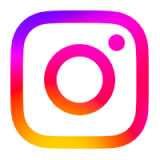
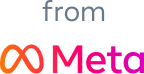
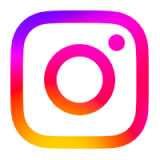
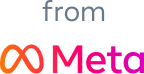
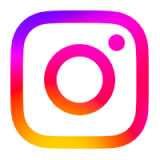
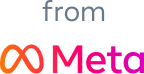

Error scraping followers of gianfrancesco.paolo: challenge_required
number of following: 578
Scraping friends of user: gianfrancesco.paolo
Scraping following of user: gianfrancesco.paolo


Status 200: JSONDecodeError in public_request (url=https://www.instagram.com/accounts/suspended/) >>> <!DOCTYPE html><html class="_9dls _ar44" lang="en" dir="ltr"><head><link data-default-icon="https://static.cdninstagram.com/rsrc.php/v4/yI/r/VsNE-OHk_8a.png" rel="icon" sizes="192x192" href="https://static.cdninstagram.com/rsrc.php/v4/yI/r/VsNE-OHk_8a.png" /><title>Instagram</title><meta name="bingbot" content="noarchive" /><meta name="robots" content="noarchive, noimageindex" /><meta charset="utf-8" /><meta name="apple-mobile-web-app-status-bar-style" content="default" /><meta name="mobile-web-app-capable" content="yes" /><meta id="viewport" name="viewport" content="width=device-width, initial-scale=1, minimum-scale=1, maximum-scale=2, viewport-fit=cover" /><meta name="theme-color" content="#ffffff" /><meta name="theme-color" content="#000000" media="(prefers-color-scheme: dark)" /><link rel="apple-touch-icon" sizes="76x76" href="https://static.cdninstagram.com/rsrc.php/v4/yR/r/lam-fZ
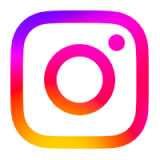
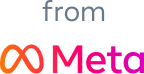
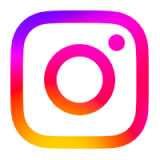
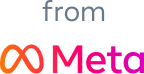
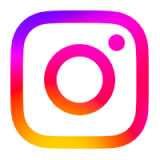
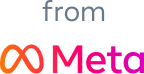

Error scraping following of gianfrancesco.paolo: JSONDecodeError Expecting value: line 1 column 1 (char 0) while opening https://www.instagram.com/graphql/query/
SAVING DATA
START ITERATION 2 / 2
---------------------
RANKING USERS AGAIN
---------------------
[('_bennuzz_', 0.07), ('francescaapicozzi', 0.066)]
[('bereket__bellini', 0.065), ('luca___davide', 0.065)]
[('ste.uslo', 0.064), ('_gaiaromiti', 0.064)]
[('wjzardx', 0.063), ('sofia.giacometti', 0.063)]
[('danicellaa', 0.063), ('saraamattiuz', 0.062)]
[('totttaaa_', 0.062), ('chiaaraluongo', 0.062)]
[('silviiia.g', 0.061), ('laura_sirna', 0.061)]
[('giorgiaapicozzi', 0.061), ('stasic.latin', 0.061)]
[('lisaarizzi', 0.06), ('donfra_smilzo', 0.06)]
[('marti_borro', 0.06), ('letirimoldi', 0.06)]
[('martaa.banfi', 0.059), ('alessandrooggioni_', 0.059)]
[('giuliamantegazzaa', 0.058), ('_filippocolombo', 0.057)]
[('angie.borghi', 0.057), ('frabanfi_', 0.056)]
[('chiaraagarbelli', 0.056), ('mary_pastu_', 0.056)]
[('_alecantoni_', 0.056)

In [ ]:

NITER = 2
FFmax = 2500
topk = 10

for iteration in range(NITER):

    #time.sleep(np.random.randint(1, 3)) #sleep between iterations

    print(f"START ITERATION {iteration+1} / {NITER}")

    # RANKING BLOCK
    print('---------------------')
    print('RANKING USERS AGAIN')
    users_list = list(main_data['users_ids'].keys())
    degrees = exploration_score(users_list, main_data['main_users'], main_data['friends_list'])
    scores = iterated_degree_voting_normalized(users_list, main_data['main_users'], main_data['friends_list'], 
                                remove_main=True,
                                iter = 5)
    print('---------------------')
    ranked_users, ranked_scores = rank_users(scores)
    ranks = dict(zip(ranked_users, ranked_scores))
    res = [(str(ranked_users[i]), float(np.round(ranks[ranked_users[i]],3))) for i in range(100)]
    print_list_as_table(res, 3)
    # print(ranked_users[0:50])
    # print(ranked_scores[0:50])
    print('---------------------')


    try:

        # SCRAPING WHILE BLOCK


        max_level = np.max(ranked_scores)
        pass_max = True

        while pass_max:
            
            filtered_users = [ranked_users[i] for i in range(len(ranked_users)) if (ranked_scores[i]<=max_level) and (ranked_scores[i]>=(max_level-2))]
            if len(filtered_users) > topk:
                filtered_users = filtered_users[0:(topk-1)]

            max_level -= 1
            if max_level < 1:
                pass_max = False

            subscores = {}

            for username in filtered_users:

                if username not in set(list(main_data['users_info'].keys())):
                    update_user_info(username)
                else:
                    print(f"User {username} already in main_data.")

                #subscores[username] = 100000 - (main_data['users_info'][username]['followers_count'] + main_data['users_info'][username]['following_count'])
                FF = main_data['users_info'][username]['followers_count'] + main_data['users_info'][username]['following_count']
                #gain = 1 - degrees[username]/FF
                deg = degrees[username]
                subscores[username] = (1 - deg/FF) * (FFmax - FF)


            subranked_users, subranked_scores = rank_users(subscores)
            subranks = dict(zip(subranked_users, subranked_scores))
            res = [(str(ranked_users[i]), float(np.round(subranks[subranked_users[i]],3))) for i in range(len(subranks.keys()))]
            print_list_as_table(res, 5)

            # print('subscores:')
            # print(subscores)

            # print('subranks:')
            # print(subranked_users)

            i = 0
            pass_next = True
            pass_max = False

            while pass_next:

                pass_next = False

                winner = subranked_users[i]
                print(f"Next user to scrape: {winner}")
                username = winner
                main_data['main_users'].append(username) #here update the main users list

                #get followers
                if not main_data['users_info'][username]['scraped_followers']:
                    if (not main_data['users_info'][username]['is_private']) and (not main_data['users_info'][username]['scraped_followers']):
                        print(f"number of followers: {main_data['users_info'][username]['followers_count']}")
                        update_user_followers(username)
                    else:
                        pass_next = True
                        print(f"user {username} is private")
                else:
                    pass_next = True
                    print(f"Followers of user {username} already scraped")


                #get following
                if not main_data['users_info'][username]['scraped_following']:
                    if (not main_data['users_info'][username]['is_private']) and (not main_data['users_info'][username]['scraped_following']):
                        print(f"number of following: {main_data['users_info'][username]['following_count']}")
                        update_user_following(username)
                    else:
                        pass_next = True
                        print(f"user {username} is private")
                else:
                    pass_next = True
                    print(f"Following of user {username} already scraped")

                i+=1
                if i >= len(subranked_users):
                    pass_next = False
                    pass_max = True


        # SAVE BLOCK
        print('SAVING DATA')
        save_json(main_data, 'my_data.json')

    except Exception as e:
        print(f"Error during iteration {iteration+1}: {e}")
        continue


In [144]:
subscores

{np.str_('_bennuzz_'): 461.4334975369458,
 np.str_('francescaapicozzi'): 316.8255280073462,
 np.str_('alice_guaglianone'): 0,
 np.str_('bereket__bellini'): 534.4066496163683,
 np.str_('luca___davide'): 444.9022482893451,
 np.str_('mittamartina'): 1141.1114457831325,
 np.str_('ste.uslo'): 1260.7011686143574,
 np.str_('_gaiaromiti'): 1185.6939890710382}

# to remove